<a href="https://colab.research.google.com/github/Tribo310/MEARN/blob/main/nomio_tusul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="3WSlBQOLxQQbbDVYHJU2")
project = rf.workspace("nomin-g").project("final-tusul-fhl6y")
dataset = project.version(1).download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Final-tusul-1 in yolov8:: 100%|██████████| 8425/8425 [00:05<00:00, 1637.26it/s]


In [4]:
!pip install ultralytics
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.info()
results = model.train(data="/content/Final-tusul-1/data.yaml", epochs=20, imgsz=512, batch=8)

results.results_dict

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Final-tusul-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=Fals

{'metrics/precision(B)': 0.4832543735402552,
 'metrics/recall(B)': 0.5285733065415187,
 'metrics/mAP50(B)': 0.49714535819586514,
 'metrics/mAP50-95(B)': 0.32681212832558604,
 'fitness': 0.32681212832558604}

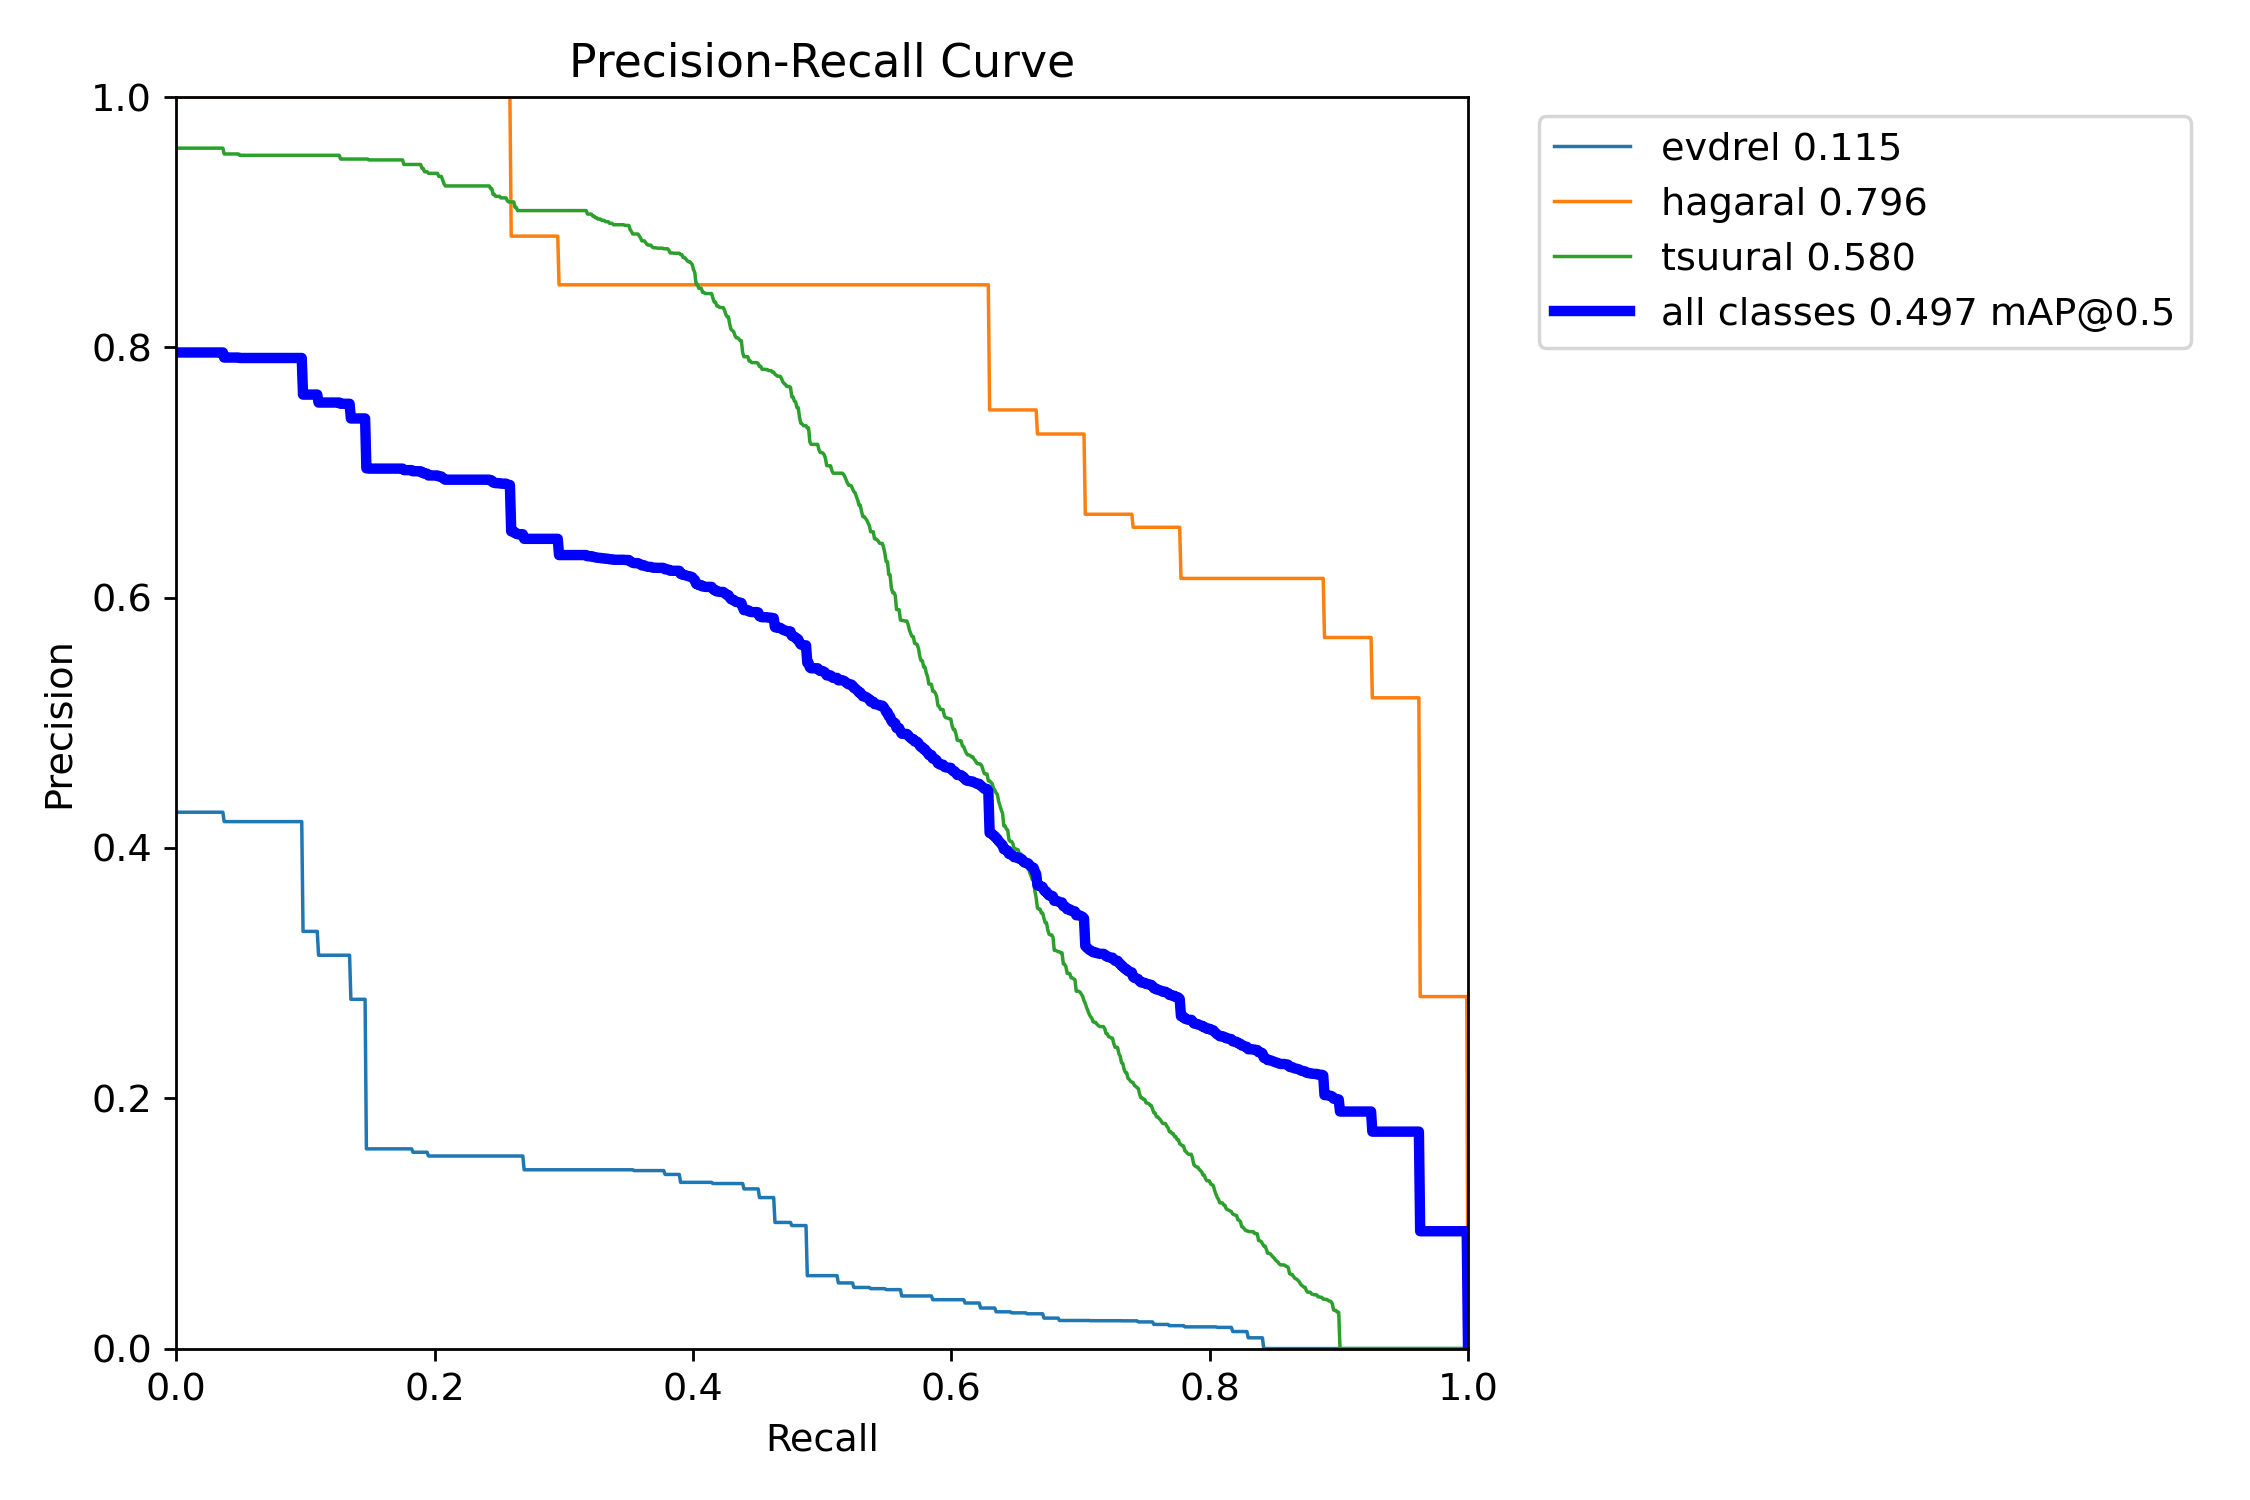

In [8]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train-2/BoxPR_curve.png'))

In [10]:
!pip install supervision ultralytics
from ultralytics import YOLO
import supervision as sv
from tqdm import tqdm
import os

# =========================
# Video paths (Update these for Colab)
# =========================
# Upload your video to Colab and change this filename
SOURCE_VIDEO_PATH = "/content/test.mp4"
TARGET_VIDEO_PATH = "/content/test_output.mp4"

# =========================
# Load trained YOLO model
# =========================
YOLO_MODEL_PATH = "/content/runs/detect/train-2/weights/best.pt"
if not os.path.exists(YOLO_MODEL_PATH):
    print(f"Warning: {YOLO_MODEL_PATH} not found. Ensure training finished.")
else:
    yolo_model = YOLO(YOLO_MODEL_PATH)

    # =========================
    # Annotators
    # =========================
    # Mapping colors to your 3 road classes
    colors = sv.ColorPalette.from_hex([
        "#00BFFF",  # evdrel (Class 0 or 1 depending on your yaml)
        "#FF0000",  # hagaral
        "#FFD700"   # tsuural
    ])

    box_annotator = sv.BoxAnnotator(color=colors, thickness=2)
    label_annotator = sv.LabelAnnotator(color=colors, text_thickness=2)

    # =========================
    # Video setup
    # =========================
    video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
    frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

    # ByteTrack for temporal consistency
    tracker = sv.ByteTrack()

    with sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info) as video_sink:
        for frame in tqdm(frame_generator, desc="Processing Road Video"):
            # YOLO inference
            result = yolo_model.predict(frame, conf=0.25)[0]
            detections = sv.Detections.from_ultralytics(result)

            # Apply Non-Max Suppression
            detections = detections.with_nms(threshold=0.5)

            # Update tracker
            detections = tracker.update_with_detections(detections)

            # Map class IDs to names from model
            labels = [
                f"{yolo_model.model.names[class_id]} {conf:.2f}"
                for class_id, conf in zip(detections.class_id, detections.confidence)
            ]

            # Annotate frame
            annotated_frame = frame.copy()
            annotated_frame = box_annotator.annotate(
                scene=annotated_frame,
                detections=detections
            )
            annotated_frame = label_annotator.annotate(
                scene=annotated_frame,
                detections=detections,
                labels=labels
            )

            video_sink.write_frame(annotated_frame)

    print("\nRoad detection finished!")
    print(f"Saved video to: {TARGET_VIDEO_PATH}")

Processing Road Video: 0it [00:00, ?it/s]


0: 512x288 3 tsuurals, 41.1ms
Speed: 1.4ms preprocess, 41.1ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 288)


Processing Road Video: 1it [00:00,  7.55it/s]


0: 512x288 2 tsuurals, 6.8ms
Speed: 2.0ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 288)

0: 512x288 2 tsuurals, 7.3ms
Speed: 1.3ms preprocess, 7.3ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 288)

0: 512x288 2 tsuurals, 8.0ms
Speed: 1.2ms preprocess, 8.0ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 288)

0: 512x288 2 tsuurals, 6.7ms
Speed: 1.1ms preprocess, 6.7ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 288)

0: 512x288 2 tsuurals, 6.7ms
Speed: 1.2ms preprocess, 6.7ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 288)


Processing Road Video: 6it [00:00, 27.36it/s]

...


0: 512x288 (no detections), 11.3ms
Speed: 1.3ms preprocess, 11.3ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 288)

0: 512x288 (no detections), 13.2ms
Speed: 3.2ms preprocess, 13.2ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 288)

0: 512x288 (no detections), 12.8ms
Speed: 1.2ms preprocess, 12.8ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 288)

0: 512x288 (no detections), 14.6ms
Speed: 1.2ms preprocess, 14.6ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 288)


Processing Road Video: 660it [00:17, 35.51it/s]


0: 512x288 (no detections), 10.4ms
Speed: 1.3ms preprocess, 10.4ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 288)


Processing Road Video: 661it [00:17, 37.53it/s]


Road detection finished!
Saved video to: /content/test_output.mp4


In [11]:
import pandas as pd

df = pd.read_csv("runs/detect/train-2/results.csv")
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
15,16,1296.18,1.56121,1.68635,1.54484,0.42143,0.48391,0.46971,0.29262,1.57712,1.63025,1.47351,0.000368,0.000368,0.000368
16,17,1374.79,1.51072,1.61227,1.51309,0.42668,0.52504,0.47656,0.29833,1.51552,1.57934,1.44160,0.000297,0.000297,0.000297
17,18,1453.26,1.49421,1.57146,1.50446,0.48010,0.52557,0.47907,0.30925,1.51148,1.56412,1.45130,0.000226,0.000226,0.000226
18,19,1530.95,1.44432,1.52190,1.47201,0.48793,0.52778,0.49768,0.32722,1.46346,1.49728,1.41849,0.000156,0.000156,0.000156
19,20,1607.98,1.42694,1.48259,1.45406,0.53755,0.49977,0.49610,0.32271,1.46612,1.49155,1.41202,0.000085,0.000085,0.000085


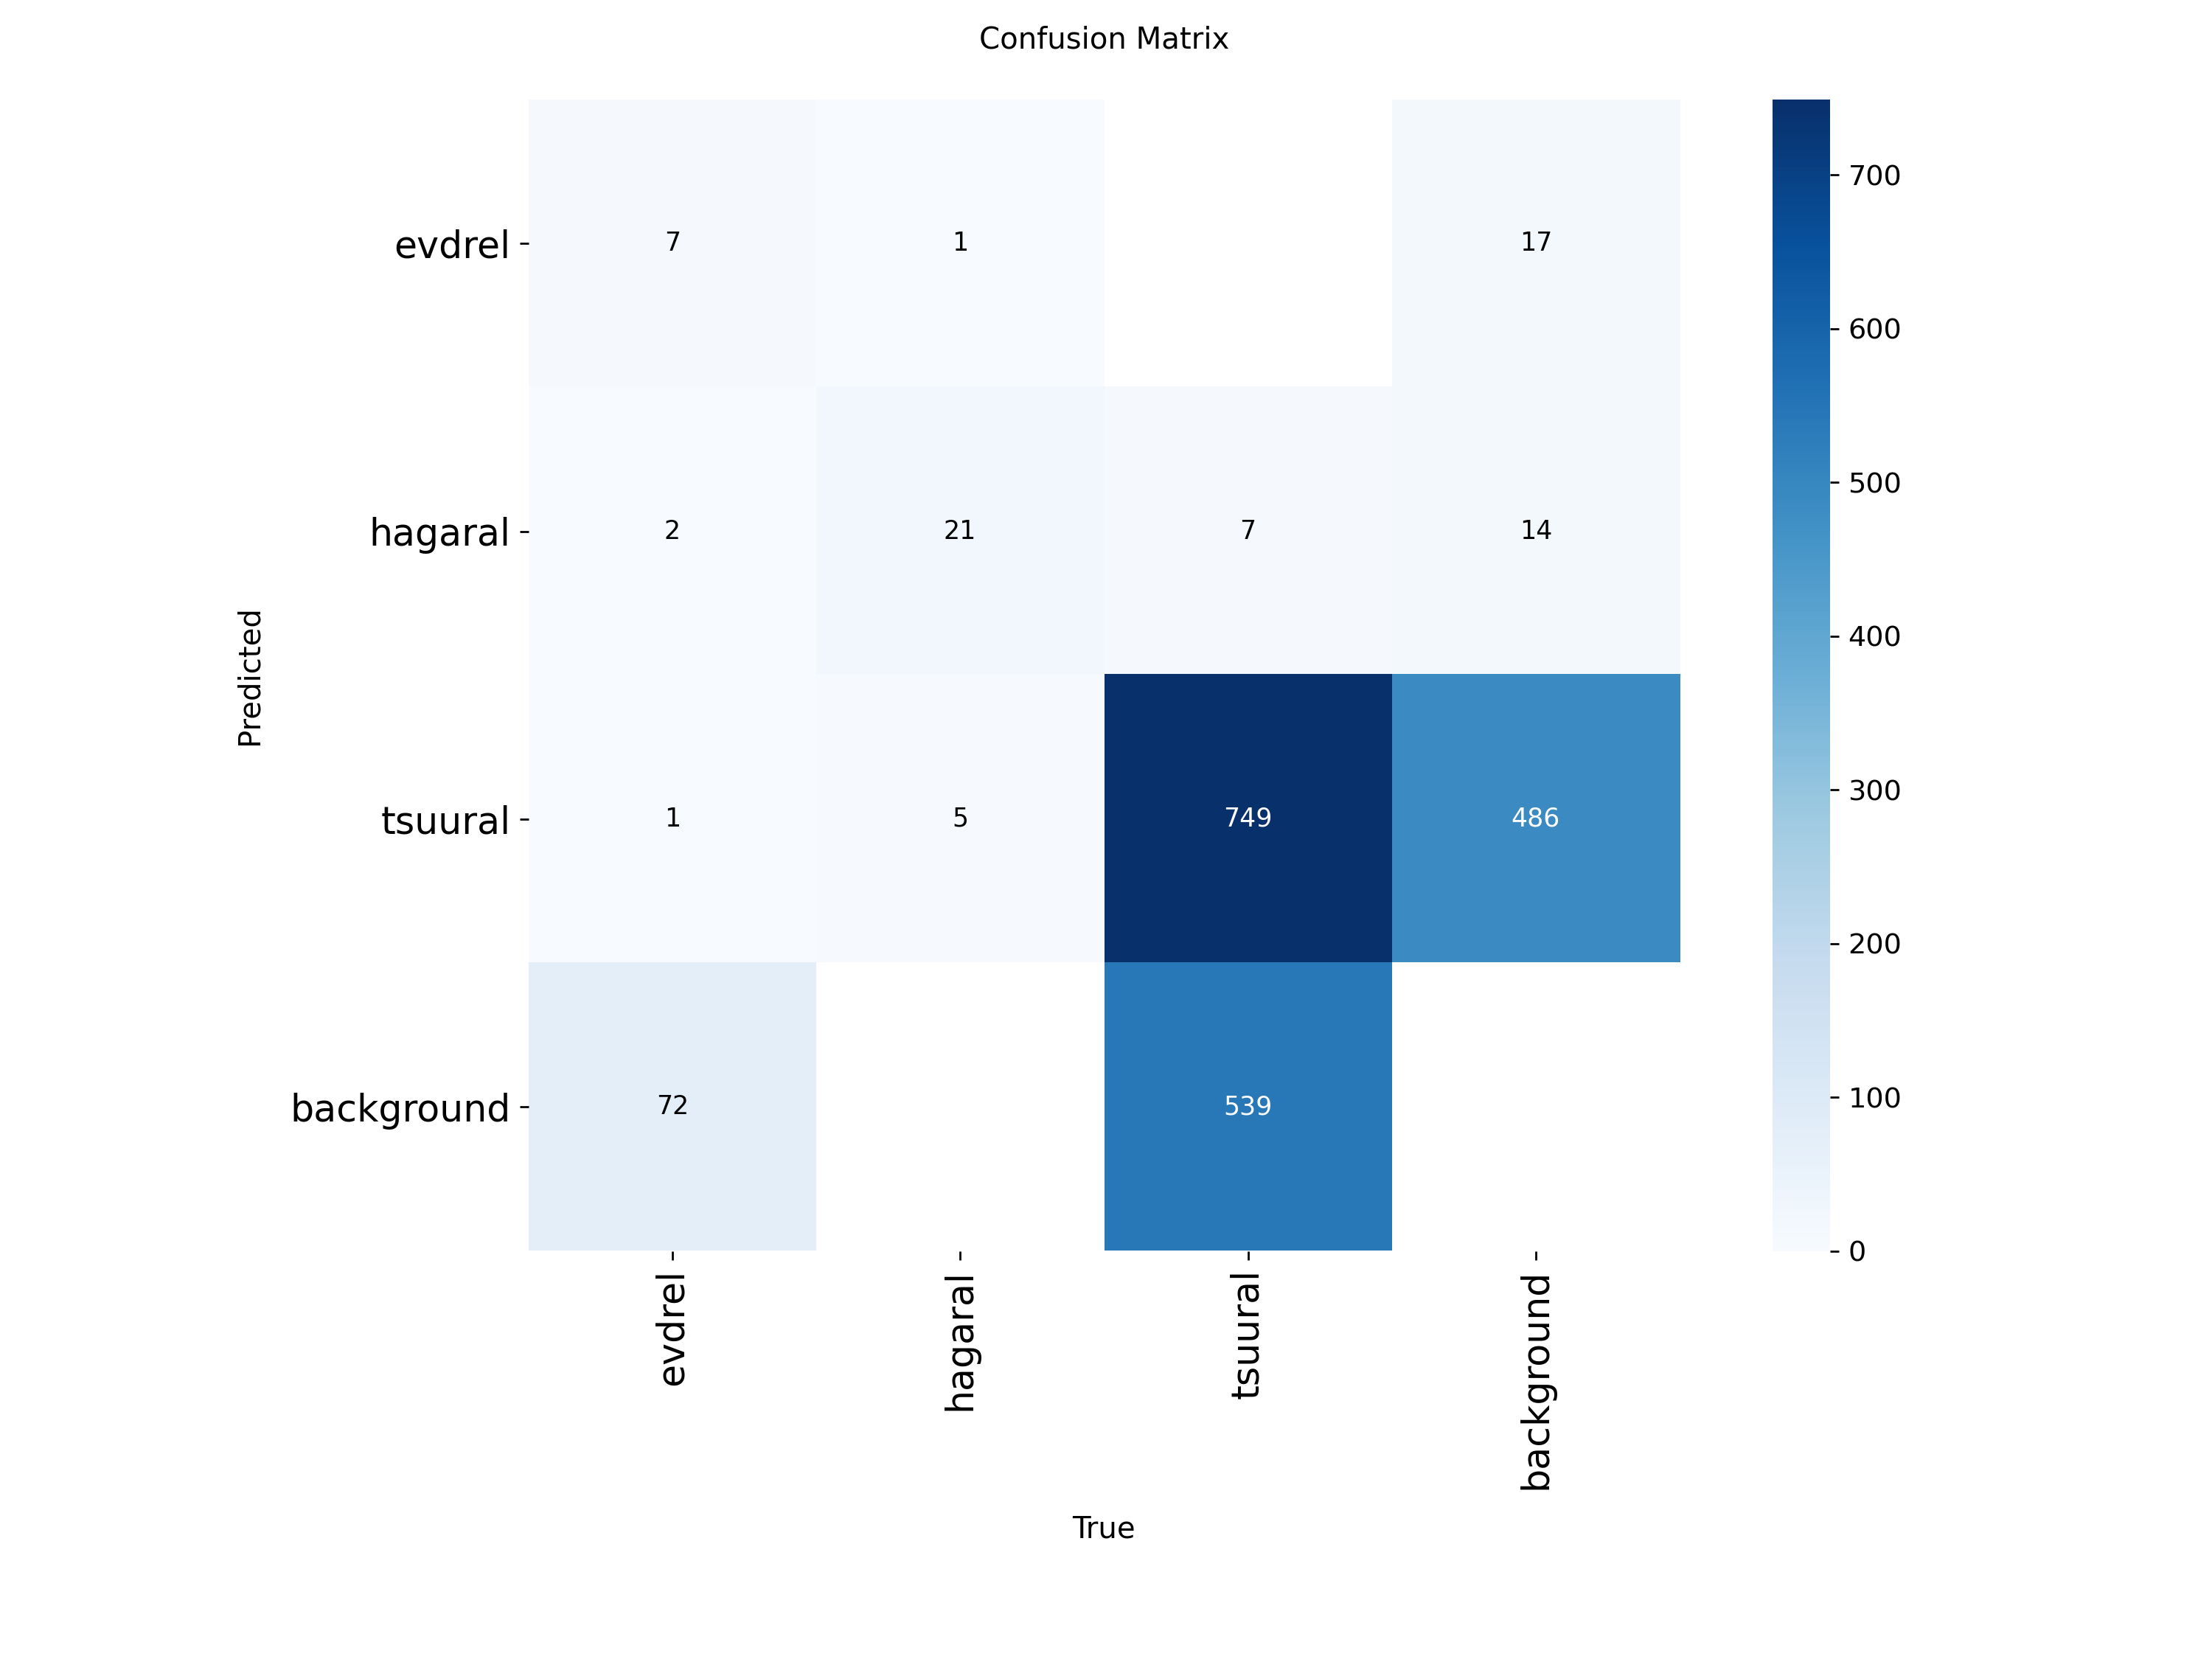

In [12]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train-2/confusion_matrix.png'))

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-2/weights/best.pt")

results = model.predict(
    source="tusultest_output.mp4",
    save=True,
    save_txt=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2054) /content/tusultest_output.mp4: 288x512 (no detections), 11.2ms
video 1/1 (frame 2/2054) /content/tusultest_output.mp4: 288x512 (no detections), 7.1ms
video 1/1 (frame 3/2054) /content/tusultest_output.mp4: 288x512 (no detections), 10.3ms
video 1/1 (frame 4/2054) /content/tusultest_output.mp4: 288x512 (no detections), 6.0ms
video 1/1 (frame 5/2054) /content/tusultest_output.mp4: 288x512 (no detections), 7.5ms
video 1/1 (frame 6/20

In [ ]:
import pandas as pd
from ultralytics import YOLO
from google.colab import files

# 1. Моделоо ачаалах (Өөрийн model.pt файлын замыг зөв зааж өгөөрэй)
model = YOLO('/content/runs/detect/train-2/weights/best.pt')

# 2. Видеог таниулж, үр дүнг 'results' хувьсагчид хадгалах
# stream=True гэвэл санах ой хэмнэнэ
results = model.predict(source='/content/tusultest_output.mp4', save=True)

# 3. Үр дүнг хадгалах жагсаалт
results_list = []

for result in results:
    # Одоо байгаа фреймийн замыг авах (эсвэл фреймийн дугаар)
    frame_path = result.path

    if len(result.boxes) > 0:
        for box in result.boxes:
            cls_id = int(box.cls[0])
            label = model.names[cls_id]
            conf = float(box.conf[0])

            results_list.append({
                'Frame': frame_path,
                'Label': label,
                'Confidence': conf
            })
    else:
        # Хэрэв юу ч илрээгүй бол тэмдэглэж болно (сонголтоор)
        results_list.append({
            'Frame': frame_path,
            'Label': 'no detections',
            'Confidence': 0
        })

# 4. DataFrame үүсгэж Excel рүү хөрвүүлэх
df = pd.DataFrame(results_list)
df.to_excel("detection_results.xlsx", index=False)

# 5. Файлаа татаж авах
files.download("detection_results.xlsx")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2054) /content/tusultest_output.mp4: 288x512 (no detections), 39.2ms
video 1/1 (frame 2/2054) /content/tusultest_output.mp4: 288x512 (no detections), 6.6ms
video 1/1 (frame 3/2054) /content/tusultest_output.mp4: 288x512 (no detections), 6.4ms
video 1/1 (frame 4/2054) /content/tusultest_output.mp4: 288x512 (no detections), 7.1ms
video 1/1 (frame 5/2054) /content/tusultest_output.mp4: 288x512 (no detections), 7.5ms
video 1/1 (frame 6/205